# Category channels analytics (PG → pandas)

Load `channel` ⋈ `channel_stat` for one category, keep top-N by latest `pv_score_rank`, plot period views for top-M.

In [5]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine, text

# notebook lives in <repo>/analysis → yt_fetcher is sibling
ROOT = Path.cwd().resolve()
if ROOT.name == "analysis":
    YT = ROOT.parent / "yt_fetcher"
else:
    YT = ROOT / "yt_fetcher" if (ROOT / "yt_fetcher").exists() else ROOT

os.chdir(YT)  # so Settings picks up yt_fetcher/.env
sys.path.insert(0, str(YT))

from app.config import settings

engine = create_engine(
    f"postgresql+psycopg2://{settings.DB_USER}:{settings.DB_PASS}"
    f"@{settings.DB_HOST}:{settings.DB_PORT}/{settings.DB_NAME}"
)
print(f"PG {settings.DB_HOST}:{settings.DB_PORT}/{settings.DB_NAME}")

PG 195.133.201.63:5433/ytr_db


In [6]:
CATEGORY_ID = 1
TOP_N = 50   # channels to load (by latest pv_score_rank)


SQL = text("""
WITH ranked AS (
    SELECT
        cs.channel_id,
        cs.pv_score_rank,
        ROW_NUMBER() OVER (
            ORDER BY cs.pv_score_rank NULLS LAST, cs.pv_view DESC NULLS LAST
        ) AS rn
    FROM channel_stat cs
    JOIN channel c ON c.channel_id = cs.channel_id
    WHERE c.category_id = :category_id
      AND c.status > 0
      AND cs.report_period = (
          SELECT MAX(cs2.report_period)
          FROM channel_stat cs2
          JOIN channel c2 ON c2.channel_id = cs2.channel_id
          WHERE c2.category_id = :category_id
            AND c2.status > 0
            AND cs2.pv_score_rank IS NOT NULL
      )
),
top_channels AS (
    SELECT channel_id
    FROM ranked
    WHERE rn <= :top_n
)
SELECT
    c.channel_id,
    c.channel_title,
    c.custom_url,
    c.category_id,
    c.status,
    c.priority,
    cs.report_period,
    cs.data_at,
    cs.subscriber_count,
    cs.channel_view_count,
    cs.video_count,
    cs.pc_view,
    cs.pc_subscriber,
    cs.pc_video,
    cs.pv_view,
    cs.pv_view_new_long,
    cs.pv_view_new_short,
    cs.pv_view_old_long,
    cs.pv_view_old_short,
    cs.pv_like,
    cs.pv_comment,
    cs.pv_score,
    cs.pv_score_rank,
    cs.pv_score_change,
    cs.pv_score_rank_change,
    cs.pv_video_long,
    cs.pv_video_short,
    cs.pv_duration
FROM channel_stat cs
JOIN channel c ON c.channel_id = cs.channel_id
JOIN top_channels t ON t.channel_id = c.channel_id
WHERE c.category_id = :category_id
ORDER BY cs.report_period, cs.pv_score_rank NULLS LAST
""")

df = pd.read_sql(
    SQL,
    engine,
    params={"category_id": CATEGORY_ID, "top_n": TOP_N},
    parse_dates=["report_period", "data_at"],
)
print(df.shape)
print("periods:", sorted(df["report_period"].dropna().unique())[:3], "…",
      sorted(df["report_period"].dropna().unique())[-3:])
print("channels:", df["channel_id"].nunique())
df.head()

(1119, 28)
periods: [Timestamp('2024-08-01 00:00:00'), Timestamp('2024-09-01 00:00:00'), Timestamp('2024-10-01 00:00:00')] … [Timestamp('2026-06-01 00:00:00'), Timestamp('2026-07-01 00:00:00'), Timestamp('2026-08-01 00:00:00')]
channels: 50


,channel_id,channel_title,custom_url,category_id,status,priority,report_period,data_at,subscriber_count,channel_view_count,...,pv_view_old_short,pv_like,pv_comment,pv_score,pv_score_rank,pv_score_change,pv_score_rank_change,pv_video_long,pv_video_short,pv_duration
0,UCdubelOloxR3wzwJG9x8YqQ,Телеканал Дождь,@tvrain,1,1,20,2024-08-01,2024-09-02 18:29:06.056283,4660000,4137557237,...,397463,2459597,316540,80506369,1,0,0,145,74,330622.0
1,UCgpSieplNxXxLXYAzJLLpng,Майкл Наки,@macknack,1,1,20,2024-08-01,2024-09-02 18:29:06.056283,1870000,1083849695,...,0,3750293,302773,59205632,2,0,0,61,0,138301.0
2,UCBzDAjLfvBUBVMMP6-K-y0w,Ходорковский LIVE,@khodorkovskylive,1,1,20,2024-08-01,2024-09-02 18:29:06.056283,2530000,1667404812,...,8967075,2399875,244787,57137837,3,0,0,214,55,302754.0
3,UCrp2It0yWUC7XcrWyBIQeKw,NEXTA Live,@nextalive,1,1,20,2024-08-01,2024-09-02 18:29:06.056283,1560000,973961664,...,0,1865777,120658,51818483,4,0,0,73,0,61241.0
4,UCUGfDbfRIx51kJGGHIFo8Rw,Максим Кац,@max_katz,1,1,20,2024-08-01,2024-09-02 18:29:06.056283,2330000,1139415893,...,0,1871304,186022,39573854,6,0,0,35,0,32585.0


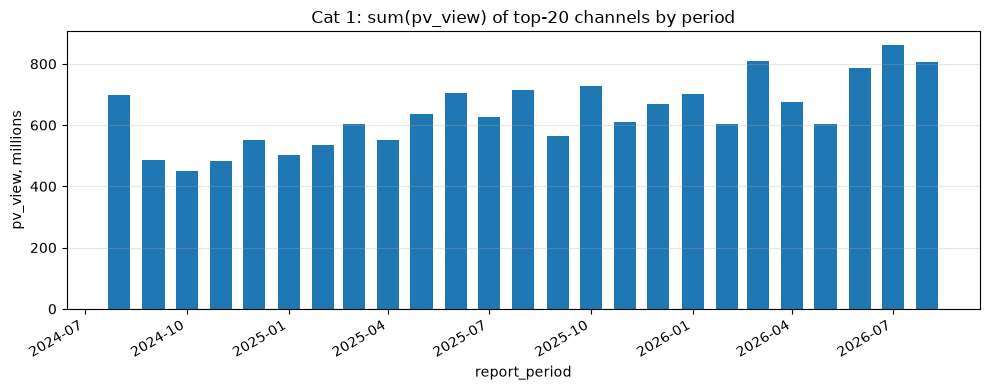

,report_period,pv_view_m
0,2024-08-01,697
1,2024-09-01,485
2,2024-10-01,449
3,2024-11-01,482
4,2024-12-01,550
5,2025-01-01,501
6,2025-02-01,534
7,2025-03-01,603
8,2025-04-01,550
9,2025-05-01,636


In [8]:
TOP_M = 20   # channels whose pv_view is summed on the chart
# Top-M by latest-period rank (among already loaded top-N)
latest = df["report_period"].max()
top_m_ids = (
    df.loc[df["report_period"] == latest]
    .sort_values(["pv_score_rank", "pv_view"], ascending=[True, False])
    .head(TOP_M)["channel_id"]
    .tolist()
)

by_period = (
    df.loc[df["channel_id"].isin(top_m_ids)]
    .groupby("report_period", as_index=False)["pv_view"]
    .sum()
    .sort_values("report_period")
)
by_period["pv_view_m"] = (by_period["pv_view"] / 1e6).round(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_period["report_period"], by_period["pv_view_m"], width=20, align="center")
ax.set_ylim(bottom=0)
ax.set_title(
    f"Cat {CATEGORY_ID}: sum(pv_view) of top-{TOP_M} channels by period"
)
ax.set_xlabel("report_period")
ax.set_ylabel("pv_view, millions")
ax.grid(True, axis="y", alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

by_period[["report_period", "pv_view_m"]]

## Spike check (Dec 2024 – Feb 2025)

Compare each top-M channel’s `pv_view` in spike months vs median of “normal” months — one channel or many?

Channels with max_ratio >= 3x baseline: 0 / 19
Top contributors to spike-window sum:


,channel_id,channel_title,spike_sum_m,max_ratio,baseline_m,share_pct
18,UCrp2It0yWUC7XcrWyBIQeKw,NEXTA Live,251.17,0.75,130.29,15.85
15,UCdubelOloxR3wzwJG9x8YqQ,Телеканал Дождь,170.42,0.72,85.06,10.75
4,UCBzDAjLfvBUBVMMP6-K-y0w,Ходорковский LIVE,159.09,0.76,83.96,10.04
2,UC7Elc-kLydl-NAV4g204pDQ,Популярная политика,134.92,1.99,27.60,8.51
16,UCgpSieplNxXxLXYAzJLLpng,Майкл Наки,109.57,1.09,38.63,6.91
10,UCVPYbobPRzz0SjinWekjUBw,Анатолий Шарий,106.37,1.39,28.53,6.71
12,UCXoAjrdHFa2hEL3Ug8REC1w,DW на русском,73.65,1.53,18.25,4.65
9,UCUGfDbfRIx51kJGGHIFo8Rw,Максим Кац,72.86,1.05,26.16,4.60
17,UCgxTPTFbIbCWfTR9I2-5SeQ,Навальный LIVE,70.88,1.72,13.70,4.47
0,UC101o-vQ2iOj9vr00JUlyKw,varlamov,66.33,1.37,17.64,4.18


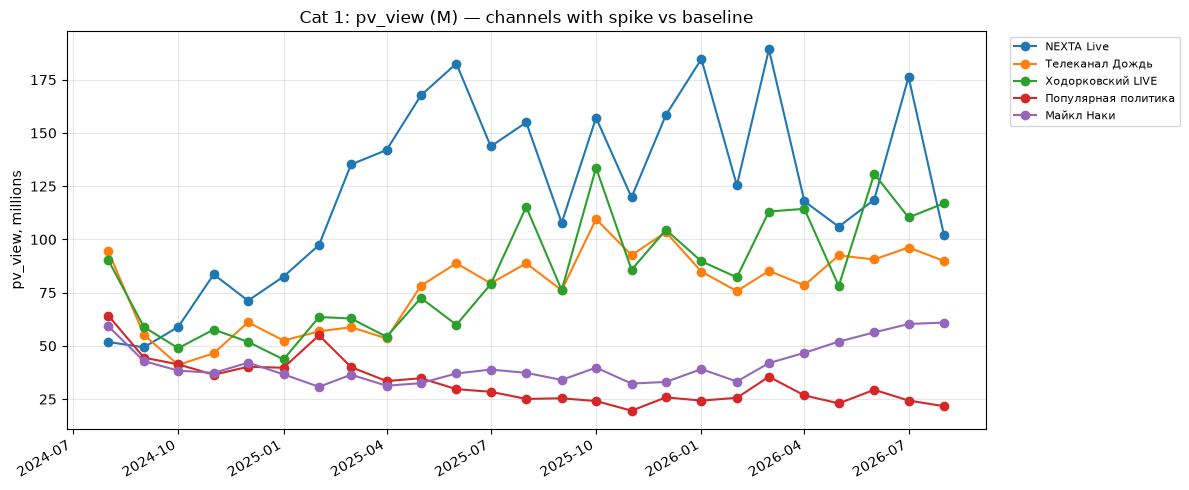

pv_view_m                            ratio             \
report_period       2024-12-01 2025-01-01 2025-02-01 2024-12-01 2025-01-01   
channel_title                                                                
NEXTA Live               71.24      82.55      97.39       0.55       0.63   
Телеканал Дождь          61.10      52.52      56.81       0.72       0.62   
Ходорковский LIVE        51.89      43.65      63.56       0.62       0.52   
Майкл Наки               42.13      36.64      30.79       1.09       0.95   
Популярная политика      40.20      39.74      54.98       1.46       1.44   
Анатолий Шарий           39.64      32.92      33.82       1.39       1.15   
DW на русском            27.94      23.99      21.71       1.53       1.31   
Максим Кац               27.52      24.11      21.23       1.05       0.92   
ВОТ ТАК                  25.70      14.56      12.10       1.43       0.81   
varlamov                 24.09      21.81      20.43       1.37       1.24   
Навальный LIVE           23.63      23.63      23.63       1.72       1.72   
И Грянул Грэм            22.52      22.43      19.58       0.98       0.97   
Обманутый Россиянин      22.20      22.73      18.10       1.06       1.08   
The Breakfast Show       18.93      16.93      19.53       0.61       0.54   
Редакция                 15.15      10.13      10.44       1.13       0.75   

                                
report_period       2025-02-01  
channel_title                   
NEXTA Live                0.75  
Телеканал Дождь           0.67  
Ходорковский LIVE         0.76  
Майкл Наки                0.80  
Популярная политика       1.99  
Анатолий Шарий            1.19  
DW на русском             1.19  
Максим Кац                0.81  
ВОТ ТАК                   0.67  
varlamov                  1.16  
Навальный LIVE            1.72  
И Грянул Грэм             0.85  
Обманутый Россиянин       0.86  
The Breakfast Show        0.63  
Редакция                  0.78

Channels with max_ratio >= 3x baseline: 0 / 19
Top contributors to spike-window sum:


,channel_id,channel_title,spike_sum_m,max_ratio,baseline_m,share_pct
18,UCrp2It0yWUC7XcrWyBIQeKw,NEXTA Live,251.17,0.75,130.29,15.85
15,UCdubelOloxR3wzwJG9x8YqQ,Телеканал Дождь,170.42,0.72,85.06,10.75
4,UCBzDAjLfvBUBVMMP6-K-y0w,Ходорковский LIVE,159.09,0.76,83.96,10.04
2,UC7Elc-kLydl-NAV4g204pDQ,Популярная политика,134.92,1.99,27.60,8.51
16,UCgpSieplNxXxLXYAzJLLpng,Майкл Наки,109.57,1.09,38.63,6.91
10,UCVPYbobPRzz0SjinWekjUBw,Анатолий Шарий,106.37,1.39,28.53,6.71
12,UCXoAjrdHFa2hEL3Ug8REC1w,DW на русском,73.65,1.53,18.25,4.65
9,UCUGfDbfRIx51kJGGHIFo8Rw,Максим Кац,72.86,1.05,26.16,4.60
17,UCgxTPTFbIbCWfTR9I2-5SeQ,Навальный LIVE,70.88,1.72,13.70,4.47
0,UC101o-vQ2iOj9vr00JUlyKw,varlamov,66.33,1.37,17.64,4.18


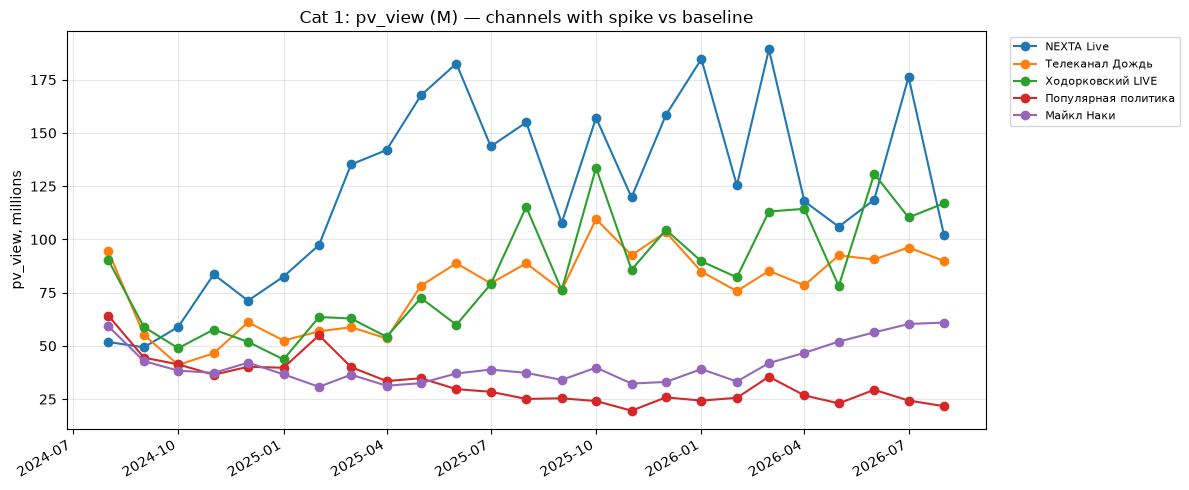

pv_view_m                            ratio             \
report_period       2024-12-01 2025-01-01 2025-02-01 2024-12-01 2025-01-01   
channel_title                                                                
NEXTA Live               71.24      82.55      97.39       0.55       0.63   
Телеканал Дождь          61.10      52.52      56.81       0.72       0.62   
Ходорковский LIVE        51.89      43.65      63.56       0.62       0.52   
Майкл Наки               42.13      36.64      30.79       1.09       0.95   
Популярная политика      40.20      39.74      54.98       1.46       1.44   
Анатолий Шарий           39.64      32.92      33.82       1.39       1.15   
DW на русском            27.94      23.99      21.71       1.53       1.31   
Максим Кац               27.52      24.11      21.23       1.05       0.92   
ВОТ ТАК                  25.70      14.56      12.10       1.43       0.81   
varlamov                 24.09      21.81      20.43       1.37       1.24   
Навальный LIVE           23.63      23.63      23.63       1.72       1.72   
И Грянул Грэм            22.52      22.43      19.58       0.98       0.97   
Обманутый Россиянин      22.20      22.73      18.10       1.06       1.08   
The Breakfast Show       18.93      16.93      19.53       0.61       0.54   
Редакция                 15.15      10.13      10.44       1.13       0.75   

                                
report_period       2025-02-01  
channel_title                   
NEXTA Live                0.75  
Телеканал Дождь           0.67  
Ходорковский LIVE         0.76  
Майкл Наки                0.80  
Популярная политика       1.99  
Анатолий Шарий            1.19  
DW на русском             1.19  
Максим Кац                0.81  
ВОТ ТАК                   0.67  
varlamov                  1.16  
Навальный LIVE            1.72  
И Грянул Грэм             0.85  
Обманутый Россиянин       0.86  
The Breakfast Show        0.63  
Редакция                  0.78

In [4]:
SPIKE_PERIODS = pd.to_datetime(["2024-12-01", "2025-01-01", "2025-02-01"])
TOP_M = 20  # same set as chart; self-contained if plot cell not run

latest = df["report_period"].max()
top_m_ids = (
    df.loc[df["report_period"] == latest]
    .sort_values(["pv_score_rank", "pv_view"], ascending=[True, False])
    .head(TOP_M)["channel_id"]
    .tolist()
)

sub = df.loc[df["channel_id"].isin(top_m_ids)].copy()
sub["pv_view_m"] = sub["pv_view"] / 1e6

# baseline = median pv_view outside spike window (same top-M set)
base = (
    sub.loc[~sub["report_period"].isin(SPIKE_PERIODS)]
    .groupby("channel_id")["pv_view"]
    .median()
    .rename("baseline_pv")
)

spike = (
    sub.loc[sub["report_period"].isin(SPIKE_PERIODS)]
    .merge(base, on="channel_id")
    .assign(
        ratio=lambda x: x["pv_view"] / x["baseline_pv"].replace(0, pd.NA),
        pv_view_m=lambda x: x["pv_view"] / 1e6,
        baseline_m=lambda x: x["baseline_pv"] / 1e6,
    )
)

# per channel: max ratio across spike months + share of spike-month sum
per_ch = (
    spike.groupby(["channel_id", "channel_title"], as_index=False)
    .agg(
        spike_sum_m=("pv_view_m", "sum"),
        max_ratio=("ratio", "max"),
        baseline_m=("baseline_m", "first"),
    )
    .sort_values("spike_sum_m", ascending=False)
)
per_ch["share_pct"] = 100 * per_ch["spike_sum_m"] / per_ch["spike_sum_m"].sum()

print("Channels with max_ratio >= 3x baseline:", (per_ch["max_ratio"] >= 3).sum(), "/", len(per_ch))
print("Top contributors to spike-window sum:")
display(per_ch.head(10).round(2))

# heatmap-ish: period x channel (millions)
pivot = (
    sub.pivot_table(
        index="report_period",
        columns="channel_title",
        values="pv_view_m",
        aggfunc="sum",
    )
    .sort_index()
)
# only columns that spike hard
hot = per_ch.loc[per_ch["max_ratio"] >= 3, "channel_title"].tolist()
if not hot:
    hot = per_ch.head(5)["channel_title"].tolist()

fig, ax = plt.subplots(figsize=(12, 5))
for title in hot:
    if title in pivot.columns:
        ax.plot(pivot.index, pivot[title], marker="o", label=title[:40])
ax.set_title(f"Cat {CATEGORY_ID}: pv_view (M) — channels with spike vs baseline")
ax.set_ylabel("pv_view, millions")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# wide table: spike months only
display(
    spike.pivot_table(
        index=["channel_title"],
        columns="report_period",
        values=["pv_view_m", "ratio"],
        aggfunc="first",
    )
    .sort_values(("pv_view_m", SPIKE_PERIODS[0]), ascending=False)
    .head(15)
    .round(2)
)

# baseline = median pv_view outside spike window (same top-M set)
base = (
    sub.loc[~sub["report_period"].isin(SPIKE_PERIODS)]
    .groupby("channel_id")["pv_view"]
    .median()
    .rename("baseline_pv")
)

spike = (
    sub.loc[sub["report_period"].isin(SPIKE_PERIODS)]
    .merge(base, on="channel_id")
    .assign(
        ratio=lambda x: x["pv_view"] / x["baseline_pv"].replace(0, pd.NA),
        pv_view_m=lambda x: x["pv_view"] / 1e6,
        baseline_m=lambda x: x["baseline_pv"] / 1e6,
    )
)

# per channel: max ratio across spike months + share of spike-month sum
per_ch = (
    spike.groupby(["channel_id", "channel_title"], as_index=False)
    .agg(
        spike_sum_m=("pv_view_m", "sum"),
        max_ratio=("ratio", "max"),
        baseline_m=("baseline_m", "first"),
    )
    .sort_values("spike_sum_m", ascending=False)
)
per_ch["share_pct"] = 100 * per_ch["spike_sum_m"] / per_ch["spike_sum_m"].sum()

print("Channels with max_ratio >= 3x baseline:", (per_ch["max_ratio"] >= 3).sum(), "/", len(per_ch))
print("Top contributors to spike-window sum:")
display(per_ch.head(10).round(2))

# heatmap-ish: period x channel (millions)
pivot = (
    sub.pivot_table(
        index="report_period",
        columns="channel_title",
        values="pv_view_m",
        aggfunc="sum",
    )
    .sort_index()
)
# only columns that spike hard
hot = per_ch.loc[per_ch["max_ratio"] >= 3, "channel_title"].tolist()
if not hot:
    hot = per_ch.head(5)["channel_title"].tolist()

fig, ax = plt.subplots(figsize=(12, 5))
for title in hot:
    if title in pivot.columns:
        ax.plot(pivot.index, pivot[title], marker="o", label=title[:40])
ax.set_title(f"Cat {CATEGORY_ID}: pv_view (M) — channels with spike vs baseline")
ax.set_ylabel("pv_view, millions")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# wide table: spike months only
display(
    spike.pivot_table(
        index=["channel_title"],
        columns="report_period",
        values=["pv_view_m", "ratio"],
        aggfunc="first",
    )
    .sort_values(("pv_view_m", SPIKE_PERIODS[0]), ascending=False)
    .head(15)
    .round(2)
)

## One channel: channel totals vs video-sum (`pv_view`)

`channel_view_count` / `pc_view` = YouTube channel MoM (all content, shorts not ÷10).  
If `pv_view` ≫ `pc_view` → video denorm/aggregation is wrong.

In [5]:
CHANNEL_ID = "UCBzDAjLfvBUBVMMP6-K-y0w"

# Always from PG — need channel_view_count / pc_view
w = pd.read_sql(
    text("""
        SELECT
            c.channel_id,
            c.channel_title,
            cs.report_period,
            cs.channel_view_count,
            cs.pc_view,
            cs.pv_view,
            cs.pv_view_new_long,
            cs.pv_view_new_short,
            cs.pv_view_old_long,
            cs.pv_view_old_short,
            cs.pv_score,
            cs.pv_score_rank
        FROM channel_stat cs
        JOIN channel c ON c.channel_id = cs.channel_id
        WHERE cs.channel_id = :channel_id
          AND cs.report_period BETWEEN DATE '2024-11-01' AND DATE '2025-03-01'
        ORDER BY cs.report_period
    """),
    engine,
    params={"channel_id": CHANNEL_ID},
    parse_dates=["report_period"],
)

w["channel_view_m"] = w["channel_view_count"] / 1e6
w["pc_view_m"] = w["pc_view"] / 1e6
w["pv_view_m"] = w["pv_view"] / 1e6
w["pv_minus_pc_m"] = (w["pv_view"] - w["pc_view"]) / 1e6
w["pv_over_pc"] = w["pv_view"] / w["pc_view"].replace(0, pd.NA)

print(w["channel_title"].iloc[0] if len(w) else "no rows")
display(
    w[
        [
            "report_period",
            "channel_view_m",
            "pc_view_m",
            "pv_view_m",
            "pv_minus_pc_m",
            "pv_over_pc",
            "pv_view_new_long",
            "pv_view_new_short",
            "pv_view_old_long",
            "pv_view_old_short",
        ]
    ].round(2)
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(w["report_period"], w["pc_view_m"], marker="o", label="pc_view (channel MoM)")
ax.plot(w["report_period"], w["pv_view_m"], marker="s", label="pv_view (sum video period)")
ax.set_title(f"{CHANNEL_ID}: channel MoM vs video-sum (millions)")
ax.set_ylabel("views, millions")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

bad = w.loc[w["pv_view"] > w["pc_view"] * 1.05]
print("months where pv_view > pc_view (+5%):", len(bad))
if len(bad):
    display(bad[["report_period", "pc_view_m", "pv_view_m", "pv_over_pc"]].round(2))

OperationalError: (psycopg2.OperationalError) could not receive data from server: Software caused connection abort (0x00002745/10053)

[SQL: 
        SELECT
            c.channel_id,
            c.channel_title,
            cs.report_period,
            cs.channel_view_count,
            cs.pc_view,
            cs.pv_view,
            cs.pv_view_new_long,
            cs.pv_view_new_short,
            cs.pv_view_old_long,
            cs.pv_view_old_short,
            cs.pv_score,
            cs.pv_score_rank
        FROM channel_stat cs
        JOIN channel c ON c.channel_id = cs.channel_id
        WHERE cs.channel_id = %(channel_id)s
          AND cs.report_period BETWEEN DATE '2024-11-01' AND DATE '2025-03-01'
        ORDER BY cs.report_period
    ]
[parameters: {'channel_id': 'UCBzDAjLfvBUBVMMP6-K-y0w'}]
(Background on this error at: https://sqlalche.me/e/20/e3q8)